# Should you retire with MORE bonds, then buy back the stocks? ⛺
### The "bond tent" (rising equity glidepath) — a famous retirement recipe, measured on 152 years of data

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Timing_or_less_equity%3F: Busted](https://img.shields.io/badge/Timing_or_less_equity%3F-Busted-8b949e?style=flat-square)

Here's advice you will hear from serious people (it comes from a real 2014 academic paper by Wade Pfau and Michael Kitces): the most dangerous moment of your financial life is the **first decade after you retire**. A market crash then — while you're selling shares every year to live — can sink you, even if the market recovers later. That's *sequence-of-returns risk*. Their fix: retire holding **mostly bonds** (say, only 30% stocks) and then **buy the stocks back gradually** over retirement, up to 60–70%. Plotted over your whole life, your bond holdings look like a **tent** with its peak on retirement day.

It sounds airtight. We put it on the full Shiller dataset — every possible 30-year retirement since 1871 — with the standard 4%-rule withdrawals.

> 📓 Want the *t*-stats, the bootstrap and the decomposition? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**. Numbers quoted here are the frozen headline run ([docs/results.md](../docs/results.md)); every chart is drawn by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#2b6cb0"

from bond_tent_glidepath import data, strategy as st

HAVE_REAL = os.path.exists(data.SHILLER_PATH) or any(os.path.exists(p) for p in data._FALLBACKS)
if HAVE_REAL:
    DF = data.real_returns()
    EQ, BD = DF["EQ"].to_numpy(), DF["BD"].to_numpy()
    GE, GB, STARTS = st.cohort_year_returns(EQ, BD)
    DATES = DF.index[STARTS]
    print("real tape:", DF.index.min().date(), "->", DF.index.max().date(),
          "| cohorts:", GE.shape[0], "| fingerprint:", data.fingerprint(DF))
else:
    DF = GE = GB = DATES = None
    print("no Shiller cache -- real-tape cells quote the frozen numbers in R")

# frozen headline numbers (mirror of docs/results.md)
STRATS = ['s6040', 's5050', 's4060', 'rising', 'declining']
R = {'start': '1871-02', 'end': '2023-06', 'months': 1829, 'fingerprint': '7246f42140ba', 'ann_eq': 6.9, 'ann_bd': 2.39, 'premium': 4.52, 'n_cohorts': 1470, 'cohort_start': '1871-02', 'cohort_end': '1993-07', 'cost_bps': 10, 'strats': ['s6040', 's5050', 's4060', 'rising', 'declining'], 'succ': {'4.0': [96.33, 95.85, 93.81, 94.01, 95.85], '4.5': [88.71, 85.17, 77.82, 79.86, 86.05], '5.0': [75.78, 69.8, 59.86, 60.41, 73.95], '5.5': [63.4, 57.21, 51.84, 52.65, 62.65]}, 'tw': [(1.88, 1.332, 0.146, 54), (1.555, 0.985, 0.041, 61), (1.26, 0.698, 0.0, 91), (1.465, 0.824, 0.0, 88), (1.624, 1.115, 0.095, 61)], 'decomp': [('rising - 60/40 (HEADLINE)', -0.4154, -6.11, -1.429, -0.192, -2.31, -15.37, -20.0, 1.36), ('rising - 50/50 (SHAPE)', -0.0904, -1.85, -0.328, -0.024, -1.84, -9.39, -11.43, 1.23), ('rising - declining (TIMING)', -0.1592, -1.53, -0.619, -0.035, -1.84, -13.54, -17.96, 3.13), ('50/50 - 60/40 (ALLOCATION)', -0.325, -5.92, -1.126, -0.128, -0.48, -5.99, -8.91, 0.55)], 'safemax': [3.68, 3.61, 3.53, 3.57, 3.62], 'cape': {'n_valid': 1351, 'n_q4': 338, 'rows': {'4.0': [84.0, 82.0, 73.1, 74.3, 82.0], '4.5': [58.6, 50.3, 37.6, 39.6, 51.8], '5.0': [35.8, 30.5, 26.0, 27.2, 31.7]}}, 'famous': {'1929-09': [0.39, 0.463, 0.466, 1.251, 0.0], '1966-01': [0.0, 0.0, 0.0, 0.0, 0.0], '1972-12': [0.223, 0.172, 0.11, 0.24, 0.068]}, 'rescue': {'n_fail_6040': 54, 'band_6040': '1964-1969', 'rising_rescue_pct': 5.6, 'n_fail_rising': 88, 'band_rising': '1961-1969'}, 'robust': [('rising 30-70 (headline)', 94.01, 60.41, 1.465, -6.11), ('rising 30-60 (Kitces-Pfau)', 93.61, 58.64, 1.338, -6.75), ('rising 30-70 by yr15 (fast)', 95.71, 68.84, 1.752, -2.25), ('rising 20-80 (deep tent)', 93.47, 57.21, 1.411, -5.67)], 'costs': {'0': (96.33, 94.01, 95.85), '10': (96.33, 94.01, 95.85), '25': (96.26, 93.95, 95.71)}, 'control': [('EXACT NULL: wr=0, iid, prem 4.5pp', 0.0, None, -0.0308, -1.05), ('TENT WORLD: wr=4%, iid, prem 0pp', 5.99, 5.65, 0.0, None), ('wr=4%, prem 2pp', 4.5, 4.02, 0.002, 1.0), ('wr=4%, prem 4.5pp (historical)', 2.54, 2.92, 0.0289, 1.59), ('wr=5%, prem 4.5pp (historical)', -3.86, -3.43, 0.0, None)]}


real tape: 1871-02-01 -> 2023-06-01 | cohorts: 1470 | fingerprint: 7246f42140ba


## The answer first

| Question | Answer |
|---|---|
| Does the bond tent make a 4%-rule retirement safer? | **No.** Across 1,470 historical 30-year retirements it *fails more often* than a plain 60/40 (**94.0%** vs **96.3%** success at 4% withdrawals — and the gap explodes at 5%). |
| Is that just because it holds less stock on average? | **Not only.** Even against a 50/50 portfolio with the *same* average stock holding, the tent loses. It even loses to its own **mirror image** (start stock-heavy, glide *down*). |
| Does it ever work? | **Yes — in 1929.** Retire into a short, sharp crash where bonds hold their value, and the tent shines (**1.25×** final wealth vs **0.39×** for 60/40). That one cohort is where the folklore comes from. |
| So what actually killed retirees historically? | **The 1966–1982 inflation grind** — fifteen years where stocks *and bonds* lost real value together. A bond tent holds MORE of the asset that was dying, and buys stocks back *after* missing the recovery. |

> The tent insures against the crash everyone remembers — and marches straight into the disaster that actually did the killing.

## 1 · The claim

> *"Sequence risk peaks at retirement. So hold your **fewest** stocks on retirement day, and raise the stock share as retirement progresses — a rising equity glidepath."* — Pfau & Kitces (2014)

The intuition is genuinely clever: if the crash comes **early**, you barely own stocks; if it comes **late**, you've had decades of growth as a cushion. Let's draw the contenders.

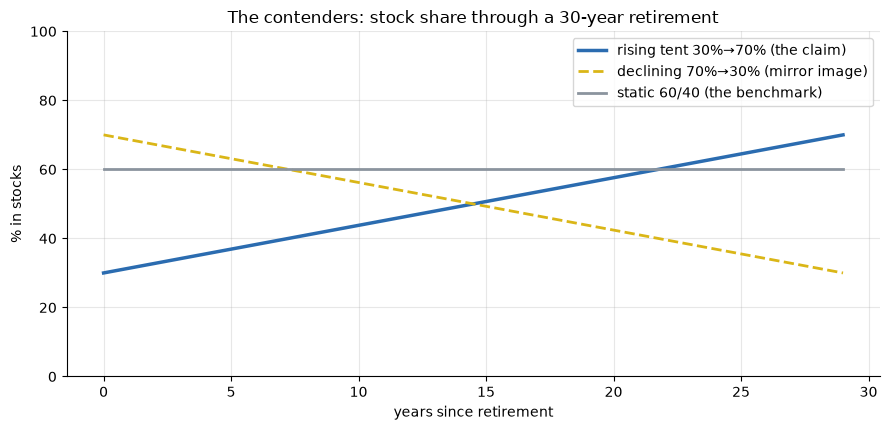

rising and declining hold the SAME average stock share (50%) -- only the timing differs


In [2]:
yrs = np.arange(30)
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.plot(yrs, 100*st.weights_for('rising'), c=BLUE, lw=2.5, label='rising tent 30%\u219270% (the claim)')
ax.plot(yrs, 100*st.weights_for('declining'), c=AMBER, lw=2, ls='--', label='declining 70%\u219230% (mirror image)')
ax.plot(yrs, 100*st.weights_for('s6040'), c=GREY, lw=2, label='static 60/40 (the benchmark)')
ax.set_xlabel('years since retirement'); ax.set_ylabel('% in stocks')
ax.set_ylim(0, 100); ax.legend(); ax.set_title('The contenders: stock share through a 30-year retirement')
plt.tight_layout(); plt.show()
print('rising and declining hold the SAME average stock share (50%) -- only the timing differs')

## 2 · So what?

Target-date funds, retirement books and a thriving corner of the advice industry sell versions of this. If the tent works, every retiree should tilt bond-heavy at 65. If it doesn't — if it actually *raises* the odds of running out of money — that's an expensive piece of folklore, and the "safety" it sells is the opposite of what it delivers.

## 3 · How would we even know?

We take Shiller's monthly data back to **1871-02** — real (inflation-adjusted) US stock returns and 10-year government bond returns — and run **every possible 30-year retirement** (1,470 of them, one starting every month from 1871-02 to 1993-07). Each retiree follows the classic 4% rule: withdraw 4% of the starting pot, inflation-adjusted, every year; rebalance annually to that year's target mix; pay 10 bps on every trade. **Success** = the money never runs out in 30 years. Then we race the tent against static mixes and against its own mirror image — same average stock share, reversed timing. That mirror race is the killer test: if "stocks late beats stocks early" is true, the tent must beat its reflection.

## 4 · The teardown — let's actually look

**Success rates first.** The share of the 1,470 historical retirements that never ran out of money:

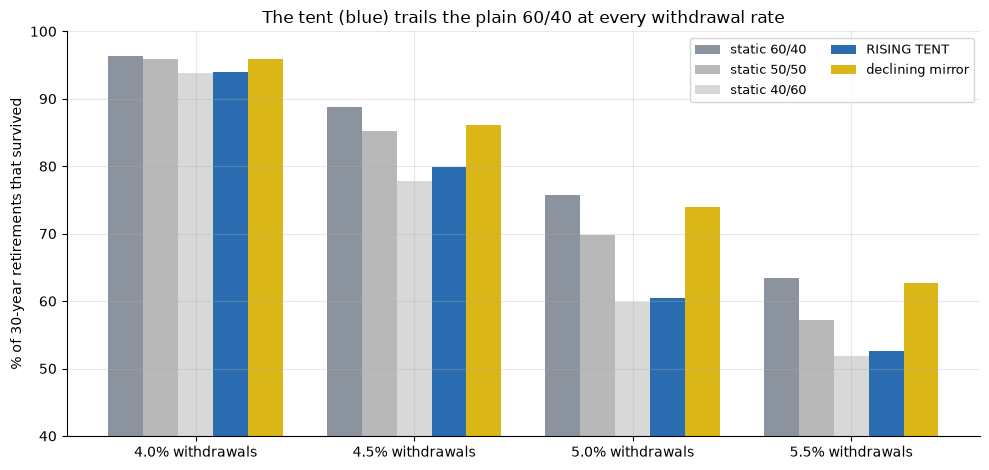

4.0%: {'s6040': np.float64(96.33), 's5050': np.float64(95.85), 's4060': np.float64(93.81), 'rising': np.float64(94.01), 'declining': np.float64(95.85)}
4.5%: {'s6040': np.float64(88.71), 's5050': np.float64(85.17), 's4060': np.float64(77.82), 'rising': np.float64(79.86), 'declining': np.float64(86.05)}
5.0%: {'s6040': np.float64(75.78), 's5050': np.float64(69.8), 's4060': np.float64(59.86), 'rising': np.float64(60.41), 'declining': np.float64(73.95)}
5.5%: {'s6040': np.float64(63.4), 's5050': np.float64(57.21), 's4060': np.float64(51.84), 'rising': np.float64(52.65), 'declining': np.float64(62.65)}


In [3]:
wrs = ['4.0','4.5','5.0','5.5']
if HAVE_REAL:
    tab = {w: [100*st.simulate(GE, GB, st.weights_for(s), wr=float(w)/100)['success'].mean()
               for s in STRATS] for w in wrs}
else:
    tab = R['succ']
x = np.arange(len(wrs)); wdt = 0.16
colors = {'s6040': GREY, 's5050': '#b8b8b8', 's4060': '#d8d8d8', 'rising': BLUE, 'declining': AMBER}
fig, ax = plt.subplots(figsize=(10.0, 4.8))
lbl = {'s6040':'static 60/40','s5050':'static 50/50','s4060':'static 40/60',
       'rising':'RISING TENT','declining':'declining mirror'}
for k, s in enumerate(STRATS):
    ax.bar(x + (k-2)*wdt, [tab[w][k] for w in wrs], wdt, color=colors[s], label=lbl[s])
ax.set_xticks(x); ax.set_xticklabels([w + '% withdrawals' for w in wrs])
ax.set_ylabel('% of 30-year retirements that survived'); ax.set_ylim(40, 100)
ax.set_title('The tent (blue) trails the plain 60/40 at every withdrawal rate')
ax.legend(ncol=2, fontsize=9); plt.tight_layout(); plt.show()
for w in wrs: print(w+'%:', {s: round(tab[w][k],2) for k, s in enumerate(STRATS)})

The tent survives **94.0%** of retirements at 4% withdrawals; plain 60/40 survives **96.3%**. Push withdrawals to 5% and the gap becomes a chasm: **60.4% vs 75.8%**. And look at the amber bars: the tent's **mirror image** — start stock-heavy, glide down, the exact *opposite* advice — beats it everywhere too. The magic ingredient ("stocks late, not early") points the **wrong way** on real history.

**But wait — 1929.** The tent's sales pitch is one specific nightmare: retiring right before a crash. Let's watch the two most famous nightmare retirements in history, month by month.

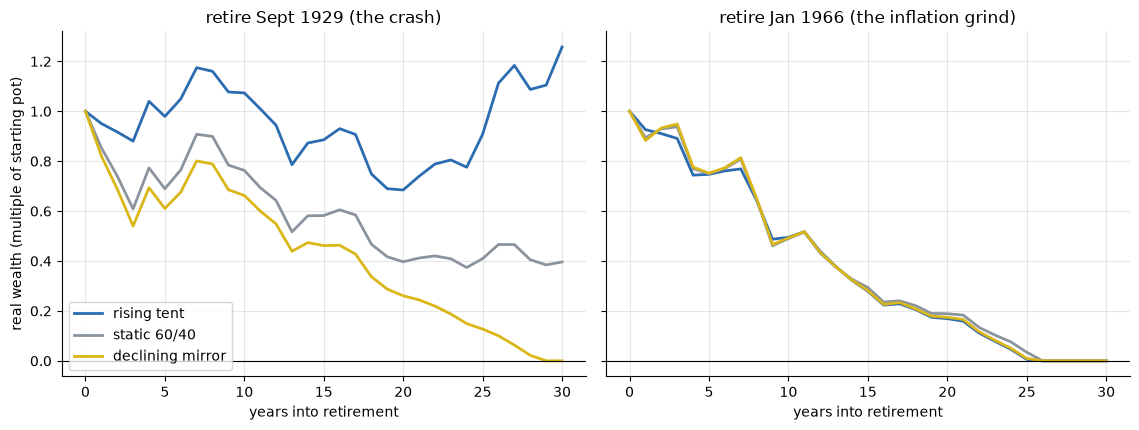

terminal wealth @4%: 1929-09 {'s6040': 0.39, 's5050': 0.463, 's4060': 0.466, 'rising': 1.251, 'declining': 0.0}
                    1966-01 {'s6040': 0.0, 's5050': 0.0, 's4060': 0.0, 'rising': 0.0, 'declining': 0.0}


In [4]:
def wealth_path(i, name, wr=0.04):
    # illustrative annual path, ex-costs
    w = st.weights_for(name); out = [1.0]
    W = 1.0 - wr; veq, vbd = W*w[0], W*(1-w[0])
    veq, vbd = veq*GE[i,0], vbd*GB[i,0]; out.append(veq+vbd)
    for j in range(1, 30):
        W = veq + vbd
        if W <= wr: out += [0.0]*(30-j); return np.array(out[:31])
        W -= wr
        veq, vbd = w[j]*W*GE[i,j], (1-w[j])*W*GB[i,j]
        out.append(veq+vbd)
    return np.array(out)
if HAVE_REAL:
    import pandas as pd
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True)
    for ax, ym, title in [(axes[0], '1929-09-01', 'retire Sept 1929 (the crash)'),
                          (axes[1], '1966-01-01', 'retire Jan 1966 (the inflation grind)')]:
        i = int(np.where(DATES == pd.Timestamp(ym))[0][0])
        for name, c, l in [('rising', BLUE, 'rising tent'), ('s6040', GREY, 'static 60/40'),
                           ('declining', AMBER, 'declining mirror')]:
            ax.plot(wealth_path(i, name), c=c, lw=2, label=l)
        ax.axhline(0, c='k', lw=.8); ax.set_title(title); ax.set_xlabel('years into retirement')
    axes[0].set_ylabel('real wealth (multiple of starting pot)'); axes[0].legend()
    plt.tight_layout(); plt.show()
print('terminal wealth @4%: 1929-09', dict(zip(STRATS, R['famous']['1929-09'])))
print('                    1966-01', dict(zip(STRATS, R['famous']['1966-01'])))

**Left panel — the tent's finest hour.** Retire in September 1929 and the tent ends with **1.25×** your starting pot while 60/40 limps to 0.39× and the mirror strategy goes **broke**. A short, deflationary crash, bonds holding value, stocks bought back cheap: everything works as advertised. This single cohort is the folklore's engine.

**Right panel — the actual killer.** Retire in January 1966 and *nothing* survives — but the tent dies no better than anything else, because from 1966 to 1982 inflation destroyed **bonds too** (our bond returns are inflation-adjusted; that's the point). The tent held *more* of the dying asset for longer, then raised its stock share *after* the 1980s recovery had already been missed. Historically the 1966-style failure vastly outnumbers the 1929-style one: **all 54** retirements that break the 60/40 at 4% start between 1964 and 1969 — and the tent rescues just **5.6%** of them while adding failures of its own (88 vs 54 for 60/40).

## 5 · The verdict

- **Signal — None.** On 1,470 historical retirements the rising tent is *less* safe than a plain 60/40 on every measure — success rate, average final wealth, worst cases. The quants notebook certifies the shortfall statistically (*t* ≈ −6) and shows it isn't a cost artefact or a shape-detail artefact.
- **Tradability — Mirage.** Nothing stops you from implementing a bond tent with two index funds. It's just that doing so historically **bought you less safety**, not more.
- **"Is the benefit clever timing, or just holding fewer stocks?" — Busted: neither.** Against a 50/50 with the same average stock share the tent still loses, and it loses to its own mirror image — the timing ingredient points the wrong way on real history. The tent's genuine benefit exists only in simulated worlds where stocks barely beat bonds (the quants notebook rebuilds exactly that world and watches the effect appear).

## 6 · Going further 🚪

- **What actually protected retirees?** Boring answers: a lower withdrawal rate (see [study 173 — the 4% rule](../../173-four-percent-rule/README.md)) and simply *owning enough stocks throughout*. The 60/40's equity engine out-insured the tent's bond cushion.
- **Why does the literature say it works?** Pfau & Kitces used Monte Carlo simulations — worlds where returns have no long inflation regimes and (in their low-return scenarios) stocks barely beat bonds. In *that* laboratory the tent really does help. History disagreed.
- **The accumulation cousin.** The same desk tested "your age in bonds" on the saving phase in [study 172 — hundred-minus-age](../../172-hundred-minus-age/README.md): same pattern, de-risking that costs more than it protects.
- **An honest caveat.** The US tape is the *best* stock market in recorded history — it flatters stock-heavy rules. And our bonds are inflation-adjusted 10-years, which the 1940s–70s crushed. Both choices are stated, not hidden; a TIPS-style bond leg (which didn't exist before 1997) would soften the 1966 story.

*Think the tent just needs the right shape? The quants notebook races four of them — the faster a tent exits its bonds, the less it loses.*